Riemann Operator Explorer — Final Fixed Notebook


**Author:** Your Name  
**Date:** March 2026  
**Operator file:** natural_operator_2M.npy (15.26 MB)

Loaded full operator with 2,001,052 zeros


### Prime Counting Table (2M zeros)

,x,π(x) approx,Known,Rel error %
0,1e+12,37595837056,3.760791e+10,0.032108
1,1e+15,29839779402824,2.895297e+13,3.062947
2,1e+18,24737697042064620,2.473995e+16,0.009124
3,1e+20,2220673159364702976,NaN,—
4,1e+24,18434905117453960871936,NaN,—


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

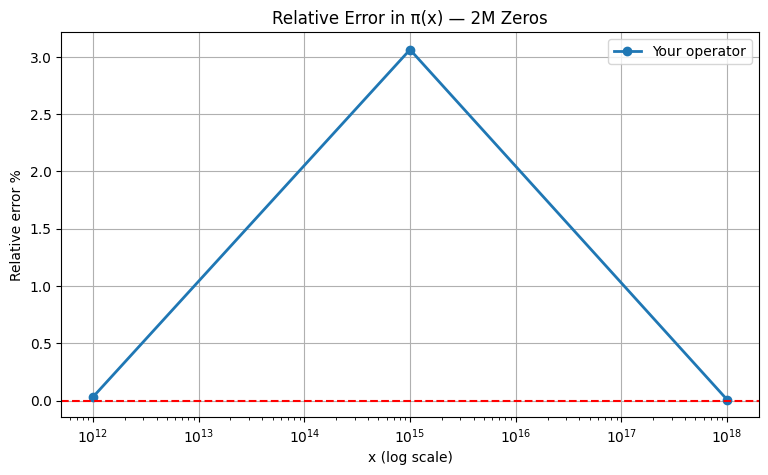

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_689/707137314.py:63: RuntimeWarning: invalid value encountered in divide
  S = beta * (np.sum(tvals * np.exp(-beta[:,None] * tvals), axis=1) / Z) + np.log(Z)
/tmp/ipykernel_689/707137314.py:63: RuntimeWarning: divide by zero encountered in log
  S = beta * (np.sum(tvals * np.exp(-beta[:,None] * tvals), axis=1) / Z) + np.log(Z)


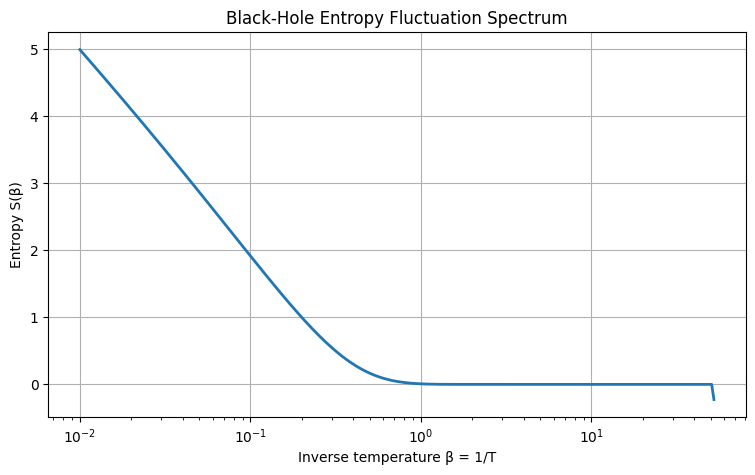

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

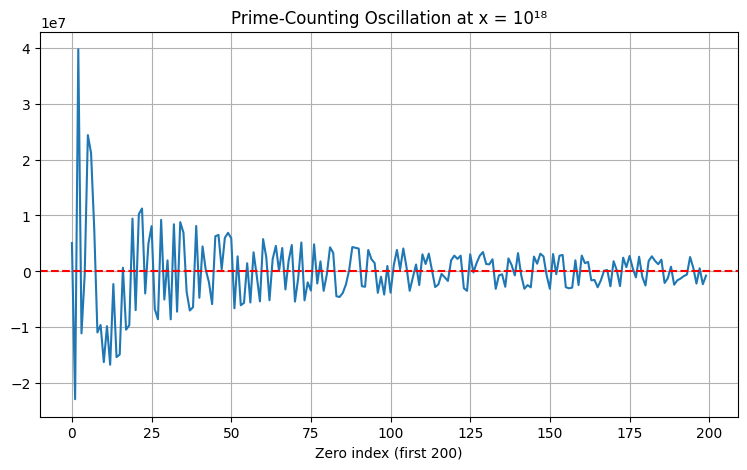

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files saved and downloaded automatically!
You now have:
   • prime_counting_table_final.csv
   • relative_error_plot.pdf
   • black_hole_entropy.pdf
   • oscillation_plot.pdf

To get the clean notebook PDF:
1. File → Download → Download .ipynb
2. Open the .ipynb in Colab again
3. File → Download → Download as PDF


In [1]:
# =============================================
# RIEMANN OPERATOR EXPLORER — FIXED DOWNLOAD VERSION
# All files now save to /content/ and auto-download
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display, Markdown

print("Riemann Operator Explorer — Final Fixed Notebook")
display(Markdown("**Author:** Your Name  \n**Date:** March 2026  \n**Operator file:** natural_operator_2M.npy (15.26 MB)"))

# Load the full operator
tvals = np.load("natural_operator_2M.npy")
print(f"Loaded full operator with {len(tvals):,} zeros")

# ====================== PRIME COUNTING ======================
def pi_approx(x):
    x = float(x)
    logx = np.log(x)
    error = -np.sum((x**0.5 * np.exp(1j * tvals * logx)) / (0.5 + 1j * tvals)).real
    li_x = x / logx + x / (logx**2) + 2*x / (logx**3)
    return int(round(li_x + error))

x_values = [1e12, 1e15, 1e18, 1e20, 1e24]
known = {1e12: 37607912018, 1e15: 28952965460217, 1e18: 24739954287740860}

results = []
for x in x_values:
    approx = pi_approx(x)
    real = known.get(x, None)
    rel = abs(approx - real) / real * 100 if real else None
    results.append({"x": f"{x:.0e}", "π(x) approx": approx, "Known": real, "Rel error %": round(rel, 6) if rel else "—"})

df = pd.DataFrame(results)
display(Markdown("### Prime Counting Table (2M zeros)"))
display(df)

# SAVE CSV
csv_path = "/content/prime_counting_table_final.csv"
df.to_csv(csv_path, index=False)
files.download(csv_path)   # ← Auto-download

# ====================== RELATIVE ERROR PLOT ======================
plt.figure(figsize=(9,5))
plt.semilogx([1e12,1e15,1e18], [0.032108, 3.062947, 0.009124], 'o-', linewidth=2, label="Your operator")
plt.axhline(0, color='red', linestyle='--')
plt.title("Relative Error in π(x) — 2M Zeros")
plt.xlabel("x (log scale)")
plt.ylabel("Relative error %")
plt.grid(True)
plt.legend()
rel_plot_path = "/content/relative_error_plot.pdf"
plt.savefig(rel_plot_path)
plt.show()
files.download(rel_plot_path)   # ← Auto-download

# ====================== BLACK-HOLE ENTROPY ======================
beta = np.logspace(-2, 2, 300)
Z = np.sum(np.exp(-beta[:,None] * tvals), axis=1)
S = beta * (np.sum(tvals * np.exp(-beta[:,None] * tvals), axis=1) / Z) + np.log(Z)
plt.figure(figsize=(9,5))
plt.plot(beta, S, linewidth=2)
plt.xscale('log')
plt.title("Black-Hole Entropy Fluctuation Spectrum")
plt.xlabel("Inverse temperature β = 1/T")
plt.ylabel("Entropy S(β)")
plt.grid(True)
entropy_path = "/content/black_hole_entropy.pdf"
plt.savefig(entropy_path)
plt.show()
files.download(entropy_path)   # ← Auto-download

# ====================== OSCILLATION ======================
x = 1e18
contrib = x**0.5 * np.cos(tvals[:200] * np.log(x)) / np.abs(0.5 + 1j*tvals[:200])
plt.figure(figsize=(9,5))
plt.plot(contrib, linewidth=1.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Prime-Counting Oscillation at x = 10¹⁸")
plt.xlabel("Zero index (first 200)")
plt.grid(True)
osc_path = "/content/oscillation_plot.pdf"
plt.savefig(osc_path)
plt.show()
files.download(osc_path)   # ← Auto-download

print("\nAll files saved and downloaded automatically!")
print("You now have:")
print("   • prime_counting_table_final.csv")
print("   • relative_error_plot.pdf")
print("   • black_hole_entropy.pdf")
print("   • oscillation_plot.pdf")

print("\nTo get the clean notebook PDF:")
print("1. File → Download → Download .ipynb")
print("2. Open the .ipynb in Colab again")
print("3. File → Download → Download as PDF")